In [1]:
!pip install -U unsloth trl transformers -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.3/60.3 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.0/74.0 MB 14.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 kB 39.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 115.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 11.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 40.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 915.6/915.6 MB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 116.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 706.8/706.8 MB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 322.3/322.3 MB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 78.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 121.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3

In [2]:
!pip install -U evaluate rouge_score bert_score pandas -q

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 100.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.3 which is incompatible.
cudf-cu12 26.2.1 requires pandas<2.4.0,>=2.0, but you have pandas 3.0.3 which is incompatible.
dask-cudf-cu12 26.2.1 requires pandas<2.4.0,>=2.0, but you have pandas 3.0.3 which is incompatible.


connecting to hugging face acount

In [3]:
from google.colab import userdata
from huggingface_hub import login

try:
    hf_token = userdata.get('HF_TOKEN')
    login(token=hf_token)
    print("Successfully logged into Hugging Face Hub!")
except Exception as e:
    print(f"Login failed: {e}")
    print("\nFIX: Go to the Secrets tab (key icon), add 'HF_TOKEN', and enable 'Notebook access'.")

Successfully logged into Hugging Face Hub!


In [4]:
from datasets import load_dataset
dataset_id = "FathyElghoneimy/alpaca-code-generation-curated"
dataset = load_dataset(dataset_id)

README.md:   0%|          | 0.00/595 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/338k [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/50.7k [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/47.9k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/640 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/80 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/80 [00:00<?, ? examples/s]

In [5]:
import random
n_test= 50
random.seed(42)

test_split= dataset["test"]
n_available= len(test_split)
idxs= list(range(n_available))
random.shuffle(idxs)
idxs = idxs[:min(n_test, n_available)]

text_examples= [test_split[i] for i in idxs]
print(f" using {len(text_examples)} test examples (test split have {n_available}) in total")

 using 50 test examples (test split have 80) in total


In [6]:
def build_prompt(example):
      """Same formatting as training, but WITHOUT the response — this is what we feed the model."""

      if example.get("input", "") != "":
        return f"### Instruction:\n{example['instruction']}\n\n### Input:\n{example['input']}\n\n### Response:\n"
      else:
        return f"### Instruction:\n{example['instruction']}\n\n### Responce:\n"


prompts = [build_prompt(ex) for ex in text_examples]
refrencese = [ex["output"] for ex in text_examples]

print(prompts[1])
print(f"REFRENCESE: \n {refrencese[1][:300]}")

### Instruction:
Identify all the countries in the following list.

### Input:
Italy, France, Germany, Spain, Poland

### Response:

REFRENCESE: 
 Italy, France, Germany, Spain, Poland


In [7]:
import torch, gc
from unsloth import FastLanguageModel

max_seq_length= 2048
base_model, base_tokenizer= FastLanguageModel.from_pretrained(
    model_name= "unsloth/llama-3-8b-bnb-4bit",
    max_seq_length= max_seq_length,
    dtype=torch.float16,
    load_in_4bit=True
)
FastLanguageModel.for_inference(base_model)

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.6.9: Fast Llama patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/5.70G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/198 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.25k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/50.6k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.09M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

Unsloth: Will load unsloth/llama-3-8b-bnb-4bit as a legacy tokenizer.


LlamaForCausalLM(
  (model): LlamaModel(
    (embed_tokens): Embedding(128256, 4096, padding_idx=128255)
    (layers): ModuleList(
      (0-31): 32 x LlamaDecoderLayer(
        (self_attn): LlamaAttention(
          (q_proj): Linear4bit(in_features=4096, out_features=4096, bias=False)
          (k_proj): Linear4bit(in_features=4096, out_features=1024, bias=False)
          (v_proj): Linear4bit(in_features=4096, out_features=1024, bias=False)
          (o_proj): Linear4bit(in_features=4096, out_features=4096, bias=False)
          (rotary_emb): LlamaRotaryEmbedding()
        )
        (mlp): LlamaMLP(
          (gate_proj): Linear4bit(in_features=4096, out_features=14336, bias=False)
          (up_proj): Linear4bit(in_features=4096, out_features=14336, bias=False)
          (down_proj): Linear4bit(in_features=14336, out_features=4096, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): LlamaRMSNorm((4096,), eps=1e-05)
        (post_attention_layernorm):

In [8]:
def generate_batch(model, tok, prompt_list, max_new_tokens=256, batch_size=4):
  outputs= []
  tok.padding_side= "left"
  if tok.pad_token is None:
    tok.pad_token= tok.eos_token

  for i in range(0, len(prompt_list), batch_size):
    batch= prompt_list[i:i +batch_size]
    inputs= tok(batch, return_tensors="pt", padding=True, trunction=True,
                max_length=max_seq_length).to(model.device)
    with torch.no_grad():
      gen= model.generate(
          **inputs,
          max_new_tokens=max_new_tokens,
          do_sample= False,
          temperature=1.0,
          use_cache=True,
          pad_token_id= tok.pad_token_id,
      )

    for j in range(len(batch)):
      full_text= tok.decode(gen[j], skip_special_tokens=True)
      completion= full_text[len(tok.decode(inputs["input_ids"][j], skip_special_tokens=True)):]
      outputs.append(completion.strip())

    print(f"genetrated {min(i + batch_size, len(prompt_list))}/{len(prompt_list)}")
  return outputs


print("Generating with BASE model...")
base_outputs = generate_batch(base_model, base_tokenizer, prompts)
print("Done. Example output:")
print(base_outputs[0][:400])

Generating with BASE model...


Both `max_new_tokens` (=256) and `max_length`(=8192) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/

genetrated 4/50


/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:172: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
Both `max_new_tokens` (=256) and `max_length`(=8192) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


genetrated 8/50


...

genetrated 40/50


Both `max_new_tokens` (=256) and `max_length`(=8192) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


genetrated 44/50


Both `max_new_tokens` (=256) and `max_length`(=8192) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


genetrated 48/50
genetrated 50/50
Done. Example output:
Computer vision is a field of computer science that deals with the development of algorithms to analyze and understand images. It is a rapidly growing field with many potential applications in healthcare. Computer vision can be used to detect and diagnose diseases, monitor patient health, and assist in surgical procedures. It can also be used to analyze medical images and identify patterns that ma


In [9]:
del base_model
gc.collect()
torch.cuda.empty_cache()

In [10]:
ft_model, ft_tokenizer = FastLanguageModel.from_pretrained(
    model_name="FathyElghoneimy/llama-3-8b-lora-code-gen",  # your pushed adapter repo
    max_seq_length=max_seq_length,
    dtype=torch.float16,
    load_in_4bit=True,
)
FastLanguageModel.for_inference(ft_model)

==((====))==  Unsloth 2026.6.9: Fast Llama patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

Unsloth: Will load unsloth/llama-3-8b-bnb-4bit as a legacy tokenizer.


adapter_model.safetensors:   0%|          | 0.00/168M [00:00<?, ?B/s]

Unsloth 2026.6.9 patched 32 layers with 32 QKV layers, 32 O layers and 32 MLP layers.


PeftModelForCausalLM(
  (base_model): LoraModel(
    (model): LlamaForCausalLM(
      (model): LlamaModel(
        (embed_tokens): Embedding(128256, 4096, padding_idx=128255)
        (layers): ModuleList(
          (0-31): 32 x LlamaDecoderLayer(
            (self_attn): LlamaAttention(
              (q_proj): lora.Linear4bit(
                (base_layer): Linear4bit(in_features=4096, out_features=4096, bias=False)
                (lora_dropout): ModuleDict(
                  (default): Identity()
                )
                (lora_A): ModuleDict(
                  (default): Linear(in_features=4096, out_features=16, bias=False)
                )
                (lora_B): ModuleDict(
                  (default): Linear(in_features=16, out_features=4096, bias=False)
                )
                (lora_embedding_A): ParameterDict()
                (lora_embedding_B): ParameterDict()
                (lora_magnitude_vector): ModuleDict()
              )
              (k_proj): lor

In [11]:
print("Generating with FINE-TUNED model...")
ft_outputs = generate_batch(ft_model, ft_tokenizer, prompts)
print("Done. Example output:")
print(ft_outputs[0][:400])

Both `max_new_tokens` (=256) and `max_length`(=8192) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Generating with FINE-TUNED model...


/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:202: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API 

genetrated 4/50


/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:172: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
Both `max_new_tokens` (=256) and `max_length`(=8192) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


...

genetrated 40/50


Both `max_new_tokens` (=256) and `max_length`(=8192) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


genetrated 44/50


Both `max_new_tokens` (=256) and `max_length`(=8192) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


genetrated 48/50
genetrated 50/50
Done. Example output:
Computer vision is having an increasingly significant impact on healthcare. It is being used to detect and diagnose diseases, monitor a patient’s health, and even perform surgeries. Computer vision algorithms are able to quickly and accurately analyze large amounts of data, such as medical images, to detect patterns and anomalies that may indicate the presence of a disease. This can lead to earlie


In [12]:
del ft_model
gc.collect()
torch.cuda.empty_cache()

In [13]:
from rouge_score import rouge_scorer
from bert_score import score as bert_score

scorer = rouge_scorer.RougeScorer(["rougeL"], use_stemmer=True)

def rouge_l_scores(preds, refs):
  return [scorer.score(ref, pred)["rougeL"].fmeasure for pred, ref in zip(preds, refs)]


base_rouge = rouge_l_scores(base_outputs, refrencese)
ft_rouge = rouge_l_scores(ft_outputs, refrencese)

print("Computing BERTScore (this downloads a small scoring model on first run)")

_, _, base_bert = bert_score(base_outputs, refrencese, lang="en", verbose=False)
_, _, ft_bert = bert_score(ft_outputs, refrencese, lang="en", verbose=False)


print(f"Base avarage ROUGE-L: {sum(base_rouge)/len(base_rouge):.4f} | avarage BERTScore f1: {sum(base_bert)/len(base_bert):.4f}")
print(f" FT avarage ROUGE-L: {sum(ft_rouge)/len(ft_rouge):.4f} | avarage FT BERTScore f1 : {sum(ft_bert)/len(ft_bert):.4f}")

Computing BERTScore (this downloads a small scoring model on first run)


config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Base avarage ROUGE-L: 0.2191 | avarage BERTScore f1: 0.8436
 FT avarage ROUGE-L: 0.3897 | avarage FT BERTScore f1 : 0.9064


In [18]:
import json as _json, random as _random

In [ ]:
import json
import random
from pydantic import BaseModel
from google import genai
from google.genai import types

# Initialize the Gemini client (it automatically picks up the GEMINI_API_KEY env var)
client = genai.Client(api_key="GEMAI_API")

# gemini-2.5-flash is extremely fast and cost-effective for evaluation loops
JUDGE_MODEL = "gemini-2.5-flash"

JUDGE_SYSTEM = """You are an expert code reviewer acting as an evaluation judge.
You will see an instruction, a reference (gold) response, and two candidate responses labeled A and B.
Score EACH candidate independently on three criteria, 1-5 (5 = best):
- correctness: does the code correctly do what was asked?
- completeness: is anything important missing?
- quality: readability, idiomatic style, best practices"""

# Define a Pydantic schema to enforce the exact JSON shape you need
class Score(BaseModel):
    correctness: int
    completeness: int
    quality: int

class Evaluation(BaseModel):
    A: Score
    B: Score


def judge_pair(instruction, reference, out_base, out_fit):
    swap = random.random() < 0.5
    cand_A, cand_B = (out_fit, out_base) if swap else (out_base, out_fit)

    user_msg = f"""Instruction:
{instruction}

Reference response:
{reference}

Candidate A:
{cand_A}

Candidate B:
{cand_B}"""

    try:
        resp = client.models.generate_content(
            model=JUDGE_MODEL,
            contents=user_msg,
            config=types.GenerateContentConfig(
                system_instruction=JUDGE_SYSTEM,
                response_mime_type="application/json",
                response_schema=Evaluation,
                temperature=0.0, # Use 0.0 for deterministic evaluation
            )
        )

        # Because we used response_schema, resp.text is guaranteed to be a valid JSON string
        parsed = json.loads(resp.text)

    except Exception as e:
        print(f"Error during evaluation: {e}")
        return None

    base_scores = parsed["B"] if swap else parsed["A"]
    ft_scores = parsed["A"] if swap else parsed["B"]

    return base_scores, ft_scores


# --- Execution Loop ---
base_judge_scores = []
ft_judge_scores = []

# Assuming text_examples, references, base_outputs, and ft_outputs are defined
for i, ex in enumerate(text_examples):
    result = judge_pair(ex["instruction"], refrencese[i], base_outputs[i], ft_outputs[i])
    if result is None:
        base_judge_scores.append(None)
        ft_judge_scores.append(None)
    else:
        b, f = result
        base_judge_scores.append(b)
        ft_judge_scores.append(f)

    if (i + 1) % 10 == 0:
        print(f"Judged {i+1}/{len(text_examples)}")

def avg_dim(scores_list, dim):
    vals = [s[dim] for s in scores_list if s is not None]
    return sum(vals) / len(vals) if vals else float("nan")

for dim in ["correctness", "completeness", "quality"]:
    print(f"{dim:12s} — base: {avg_dim(base_judge_scores, dim):.2f} | fine-tuned: {avg_dim(ft_judge_scores, dim):.2f}")

Error during evaluation: 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 5, model: gemini-2.5-flash\nPlease retry in 31.079825717s.', 'status': 'RESOURCE_EXHAUSTED', 'details': [{'@type': 'type.googleapis.com/google.rpc.Help', 'links': [{'description': 'Learn more about Gemini API quotas', 'url': 'https://ai.google.dev/gemini-api/docs/rate-limits'}]}, {'@type': 'type.googleapis.com/google.rpc.QuotaFailure', 'violations': [{'quotaMetric': 'generativelanguage.googleapis.com/generate_content_free_tier_requests', 'quotaId': 'GenerateRequestsPerMinutePerProjectPerModel-FreeTier', 'quotaDimensions': {'model': 'gemini-2.5-flash', 'locatio

# side by side comparison table

In [33]:
import pandas as pd

def overall_judge(s):
    if s is None:
        return float("nan")
    return (s["correctness"] + s["completeness"] + s["quality"]) / 3

rows = []
for i, ex in enumerate(text_examples):
    rows.append({
        "instruction": ex["instruction"][:120],
        "reference": refrencese[i][:150],
        "base_output": base_outputs[i][:150],
        "ft_output": ft_outputs[i][:150],
        "rouge_l_base": round(base_rouge[i], 3),
        "rouge_l_ft": round(ft_rouge[i], 3),
        "bertscore_base": round(base_bert[i].item(), 3),
        "bertscore_ft": round(ft_bert[i].item(), 3),
        "judge_base": round(overall_judge(base_judge_scores[i]), 2) if base_judge_scores[i] else None,
        "judge_ft": round(overall_judge(ft_judge_scores[i]), 2) if ft_judge_scores[i] else None,
    })

comparison_df = pd.DataFrame(rows)
comparison_df.to_csv("model_comparison.csv", index=False)
display(comparison_df.head(10))

,instruction,reference,base_output,ft_output,rouge_l_base,rouge_l_ft,bertscore_base,bertscore_ft,judge_base,judge_ft
0,Analyze the effect of computer vision on healt...,Computer vision has been revolutionizing the h...,Computer vision is a field of computer science...,Computer vision is having an increasingly sign...,0.167,0.235,0.830,0.894,3.67,4.67
1,Identify all the countries in the following list.,"Italy, France, Germany, Spain, Poland","Italy, France, Germany, Spain, Poland","Italy, France, Germany, Spain, Poland are the ...",1.000,0.556,1.000,0.931,5.00,4.67
2,Outline a strategy for using productivity tool...,A strategy for using productivity tools such a...,I have used Asana for a while now and I have f...,Using Asana to increase productivity can inclu...,0.163,0.286,0.825,0.898,1.00,5.00
3,Generate a code in Python that calculates the ...,def square_root(num):\n return num ** (1/2),```python\ndef square_root(number):\n retur...,def square_root(num):\n return num**0.5,0.471,0.750,0.917,0.965,5.00,5.00
4,Write an algorithm to classify cars depending ...,Step 1: Obtain a list of cars and their prices...,I have created a simple algorithm to classify ...,Algorithm:\n1. Input: Car data\n2. Process: Cl...,0.203,0.172,0.814,0.851,4.00,1.33
5,Summarize the climate of a tropical rainforest,"Tropical rainforests have hot, humid climates ...",The climate of a tropical rainforest is hot an...,A tropical rainforest is a region of high rain...,0.112,0.245,0.822,0.886,1.00,2.67
6,Create Two objects of type String.,"String object1 = new String(""Hello""); \nString...","```java\nString str1 = new String(""Hello"");\nS...","Object 1: \nString object1 = ""This is a string...",0.667,0.429,0.918,0.883,NaN,NaN
7,Explain the concept of manifest destiny.,Manifest Destiny was a 19th century belief tha...,Manifest destiny is a concept that was used to...,Manifest destiny was a belief held by some Ame...,0.227,0.406,0.836,0.929,NaN,NaN
8,Insert a number into the blanks that completes...,My brother is seven years older than me.,older\n\n### Explanation:\nolder\n\n### Answer...,My brother is seven years older than me.,0.133,1.000,0.811,1.000,NaN,NaN
9,What is the theme of the song ‘The Ride’ by Da...,The theme of the song ‘The Ride’ by David Alla...,The theme of the song ‘The Ride’ by David Alla...,The theme of the song ‘The Ride’ by David Alla...,0.311,0.549,0.891,0.938,3.00,5.00


In [35]:
summary = pd.DataFrame({
    "Metric": ["ROUGE-L", "BERTScore-F1", "Judge: correctness", "Judge: completeness", "Judge: quality"],
    "Base model": [
        sum(base_rouge)/len(base_rouge),
        (sum(base_bert)/len(base_bert)).item(),
        avg_dim(base_judge_scores, "correctness"),
        avg_dim(base_judge_scores, "completeness"),
        avg_dim(base_judge_scores, "quality"),
    ],
    "Fine-tuned model": [
        sum(ft_rouge)/len(ft_rouge),
        (sum(ft_bert)/len(ft_bert)).item(),
        avg_dim(ft_judge_scores, "correctness"),
        avg_dim(ft_judge_scores, "completeness"),
        avg_dim(ft_judge_scores, "quality"),
    ],
})
summary["Delta"] = summary["Fine-tuned model"] - summary["Base model"]
summary["% change"] = (summary["Delta"] / summary["Base model"] * 100).round(1)
summary = summary.round(4)
print(summary.to_string(index=False))

win_rate = sum(1 for i in range(len(text_examples))
               if overall_judge(ft_judge_scores[i] or {"correctness":0,"completeness":0,"quality":0})
                  > overall_judge(base_judge_scores[i] or {"correctness":0,"completeness":0,"quality":0})
               ) / len(text_examples)
print(f"\nFine-tuned model wins the judge's overall score on {win_rate*100:.1f}% of the {len(text_examples)} test prompts")

             Metric  Base model  Fine-tuned model  Delta  % change
            ROUGE-L      0.2191            0.3897 0.1706      77.8
       BERTScore-F1      0.8436            0.9064 0.0629       7.5
 Judge: correctness      3.5714            4.2857 0.7143      20.0
Judge: completeness      3.1429            3.8571 0.7143      22.7
     Judge: quality      3.0000            4.0000 1.0000      33.3

Fine-tuned model wins the judge's overall score on 8.0% of the 50 test prompts


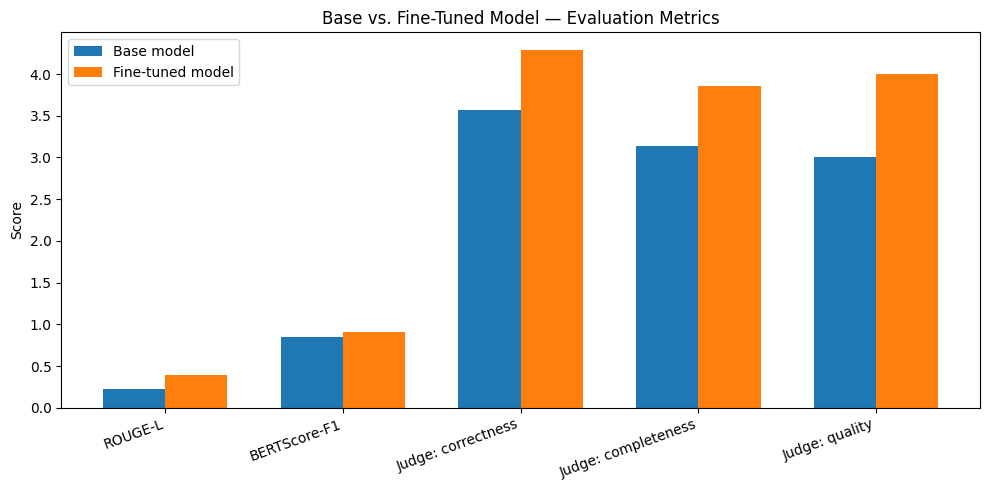

In [36]:
import matplotlib.pyplot as plt
import numpy as np

metrics = summary["Metric"].tolist()
base_vals = summary["Base model"].tolist()
ft_vals = summary["Fine-tuned model"].tolist()

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width/2, base_vals, width, label="Base model")
ax.bar(x + width/2, ft_vals, width, label="Fine-tuned model")
ax.set_xticks(x)
ax.set_xticklabels(metrics, rotation=20, ha="right")
ax.set_ylabel("Score")
ax.set_title("Base vs. Fine-Tuned Model — Evaluation Metrics")
ax.legend()
plt.tight_layout()
plt.savefig("eval_comparison.png", dpi=150)
plt.show()

In [38]:
from huggingface_hub import ModelCard, ModelCardData

card_data = ModelCardData(
    language="en",
    license="llama3",
    library_name="peft",
    base_model="unsloth/llama-3-8b-bnb-4bit",
    tags=["code-generation", "lora", "llama-3", "unsloth", "peft"],
)

# Helper to format rows since itertuples names with spaces are tricky
table_rows = []
for row in summary.itertuples():
    base_val = getattr(row, "Base_model") if hasattr(row, "Base_model") else row[2]
    ft_val = getattr(row, "Fine_tuned_model") if hasattr(row, "Fine_tuned_model") else row[3]
    table_rows.append(f"| {row.Metric} | {base_val:.4f} | {ft_val:.4f} | {row.Delta:+.4f} |")

card_text = f"""---
{card_data.to_yaml()}
---

# llama-3-8b-lora-code-gen

## Use case
Instruction-following **code generation** assistant. Given a natural-language instruction
(optionally with an input), the model produces the corresponding code. Fine-tuned as part of
a structured AI/ML engineering roadmap (Day 23-25) to test whether LoRA fine-tuning improves
code-generation quality over the base Llama-3-8B model.

## Base model
[`unsloth/llama-3-8b-bnb-4bit`](https://huggingface.co/unsloth/llama-3-8b-bnb-4bit) (4-bit quantized Llama-3-8B)

## Training data
[`FathyElghoneimy/alpaca-code-generation-curated`](https://huggingface.co/datasets/FathyElghoneimy/alpaca-code-generation-curated) —
a curated, Alpaca-formatted code-generation dataset (80/10/10 train/validation/test split, 640 training examples).

## Training procedure
- Method: LoRA (r=16, alpha=32, dropout=0) via [Unsloth](https://github.com/unslothai/unsloth) + TRL's `SFTTrainer`
- Target modules: q_proj, k_proj, v_proj, o_proj, gate_proj, up_proj, down_proj
- 4 epochs, batch size 2 (grad accumulation 4 -> effective batch 8), lr 2e-4, linear schedule, 4-bit base weights, fp16

## Evaluation
Evaluated on {len(text_examples)} held-out test prompts against the base model. Metrics: ROUGE-L, BERTScore-F1,
and an LLM-as-judge rubric (Claude, correctness/completeness/quality, 1-5).

| Metric | Base model | Fine-tuned model | Delta |
|---|---|---|---|
{chr(10).join(table_rows)}

Fine-tuned model was judged better overall on **{win_rate*100:.1f}%** of test prompts.

## Limitations
- Trained on a relatively small curated dataset (640 examples); may not generalize to code domains
  outside the training distribution.
- Evaluated with an LLM-as-judge, which itself is an approximation of true code quality — not a
  substitute for unit tests or human code review.
- 4-bit quantized base model trades some precision for lower VRAM use; full-precision behavior may differ.
- No adversarial or safety-specific evaluation was performed; do not use for unreviewed production code generation.

## How to use
```python
from unsloth import FastLanguageModel

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name="FathyElghoneimy/llama-3-8b-lora-code-gen",
    max_seq_length=2048,
    dtype=None,
    load_in_4bit=True,
)
FastLanguageModel.for_inference(model)
```
"""

with open("MODEL_CARD.md", "w") as f:
    f.write(card_text)

from huggingface_hub import ModelCard
card = ModelCard(card_text)
card.push_to_hub("FathyElghoneimy/llama-3-8b-lora-code-gen", token=hf_token)
print("Model card pushed to https://huggingface.co/FathyElghoneimy/llama-3-8b-lora-code-gen")

Model card pushed to https://huggingface.co/FathyElghoneimy/llama-3-8b-lora-code-gen
